# STAT 5290 – Project 03: Principal Component and Clustering Analysis
**Dataset:** Ozone Concentration – El Paso, TX (2015–2019)  
**Student:** Ayomiposi Sodeinde and Caleb Aregbesola | Graduate student (Problems 1–6)  
**Due:** April 3, 2025


## Setup – Imports & Configuration

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## Problem 1 – Data Collection

We load the Ozone dataset from El Paso, TX. The data contains air pollutant and
meteorological measurements collected at TCEQ ground stations from 2015–2019.
The response variable `Ozone` indicates whether ozone concentration was **High** or **Low** on a given day.


In [3]:
df_raw = pd.read_csv('ozone_dataset2.csv')

print("First five rows:")
display(df_raw.head())

print(f"\nDimensions: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")


First five rows:


,Sulferdioxide,NitricOxide,NitrogenDioxide,OxidesofNitrogen,WindSpeed,ResultantWindSpeed,ResultantWindDirection,MaximumWindGust,Std.Dev.WindDirection,OutdoorTemperature,DewPointTemperature,RelativeHumidity,SolarRadiation,UltravioletRadiation,Precipitation,PM10,Ozone
0,0.9,0.1,6.9,7.1,3.9,2.3,147,8.9,52,88.4,51.6,28.3,1.384,0.057,0.0,19.7,High
1,0.3,0.3,3.9,4.2,7.4,7.0,310,14.2,19,75.1,59.0,57.3,0.000,0.000,0.0,13.1,Low
2,0.1,0.1,3.5,3.7,8.9,8.6,289,20.3,13,77.1,59.1,53.8,0.000,0.000,0.0,22.0,Low
3,0.1,1.2,5.4,6.6,10.3,9.8,277,20.7,16,57.4,30.1,35.5,0.845,0.033,0.0,15.4,Low
4,0.2,0.2,4.2,4.4,6.1,5.0,235,14.3,34,89.6,32.8,13.4,0.676,0.021,0.0,25.0,High



Dimensions: 300 rows × 17 columns
Columns: ['Sulferdioxide', 'NitricOxide', 'NitrogenDioxide', 'OxidesofNitrogen', 'WindSpeed', 'ResultantWindSpeed', 'ResultantWindDirection', 'MaximumWindGust', 'Std.Dev.WindDirection', 'OutdoorTemperature', 'DewPointTemperature', 'RelativeHumidity', 'SolarRadiation', 'UltravioletRadiation', 'Precipitation', 'PM10', 'Ozone']


---
## Problem 2 – Data Preparation

### 2a. Variable types, missing values, and data quality


In [4]:
print("Data Types:")
print(df_raw.dtypes)
print("\nMissing values per column:")
print(df_raw.isnull().sum())
print("\nDescriptive Statistics:")
display(df_raw.describe())


Data Types:
Sulferdioxide             float64
NitricOxide               float64
NitrogenDioxide           float64
OxidesofNitrogen          float64
WindSpeed                 float64
ResultantWindSpeed        float64
ResultantWindDirection      int64
MaximumWindGust           float64
Std.Dev.WindDirection       int64
OutdoorTemperature        float64
DewPointTemperature       float64
RelativeHumidity          float64
SolarRadiation            float64
UltravioletRadiation      float64
Precipitation             float64
PM10                      float64
Ozone                      object
dtype: object

Missing values per column:
Sulferdioxide             0
NitricOxide               0
NitrogenDioxide           0
OxidesofNitrogen          0
WindSpeed                 0
ResultantWindSpeed        0
ResultantWindDirection    0
MaximumWindGust           0
Std.Dev.WindDirection     0
OutdoorTemperature        0
DewPointTemperature       0
RelativeHumidity          0
SolarRadiation            0
Ultr

,Sulferdioxide,NitricOxide,NitrogenDioxide,OxidesofNitrogen,WindSpeed,ResultantWindSpeed,ResultantWindDirection,MaximumWindGust,Std.Dev.WindDirection,OutdoorTemperature,DewPointTemperature,RelativeHumidity,SolarRadiation,UltravioletRadiation,Precipitation,PM10
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.449000,0.722333,5.189333,5.919333,6.532333,5.385000,188.773333,14.946000,34.200000,85.428333,39.227333,24.613000,0.664930,0.025807,0.001300,29.895000
std,0.429629,2.855178,5.426729,7.489781,2.918065,3.289073,90.537278,5.888787,16.410291,9.313799,15.222046,17.538979,0.542214,0.021266,0.013438,27.519837
min,0.000000,-0.500000,-1.600000,-1.500000,1.700000,0.100000,1.000000,5.800000,9.000000,55.300000,-1.800000,2.800000,0.000000,0.000000,0.000000,7.700000
25%,0.200000,0.000000,2.200000,2.500000,4.700000,3.000000,105.750000,11.300000,19.000000,79.875000,31.600000,12.800000,0.052000,0.002000,0.000000,18.275000
50%,0.300000,0.300000,3.600000,3.900000,5.650000,4.500000,170.500000,13.500000,33.000000,86.200000,41.050000,18.550000,0.686000,0.023500,0.000000,24.500000
75%,0.500000,0.700000,5.925000,6.425000,7.600000,7.100000,277.000000,17.250000,46.000000,92.700000,50.300000,31.600000,1.184000,0.046000,0.000000,33.400000
max,2.100000,43.500000,37.300000,81.100000,19.300000,18.500000,349.000000,42.200000,79.000000,102.300000,65.100000,90.100000,1.575000,0.059000,0.200000,387.500000


In [5]:
# Check for potential outliers via z-score
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
z_scores = ((df_raw[numeric_cols] - df_raw[numeric_cols].mean()) / df_raw[numeric_cols].std()).abs()
print("Columns with potential outliers (|z| > 3):")
print((z_scores > 3).sum()[lambda s: s > 0])


Columns with potential outliers (|z| > 3):
Sulferdioxide         4
NitricOxide           2
NitrogenDioxide       6
OxidesofNitrogen      5
WindSpeed             6
ResultantWindSpeed    6
MaximumWindGust       6
OutdoorTemperature    4
RelativeHumidity      5
Precipitation         2
PM10                  2
dtype: int64


**Findings:**
- All 300 rows are complete — **no missing values**.
- Variable types are appropriate: 14 numeric features (float/int) and 1 categorical target (`Ozone`).
- `NitricOxide`, `OxidesofNitrogen`, `NitrogenDioxide`, `WindSpeed`, and `MaximumWindGust` contain observations
  with |z| > 3, suggesting some extreme but plausible meteorological events; these are retained since they likely
  represent real atmospheric conditions rather than data entry errors.
- **Notable concern:** `NitricOxide` has a minimum value of −0.5, which is physically impossible.
  This likely reflects instrument calibration drift and is a recording artifact. We retain it since removing
  it would reduce sample size, but it is flagged.


### 2b. Remove Precipitation feature

In [6]:
df = df_raw.drop(columns=['Precipitation'])
print(f"Shape after removing Precipitation: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")


Shape after removing Precipitation: (300, 16)
Remaining columns: ['Sulferdioxide', 'NitricOxide', 'NitrogenDioxide', 'OxidesofNitrogen', 'WindSpeed', 'ResultantWindSpeed', 'ResultantWindDirection', 'MaximumWindGust', 'Std.Dev.WindDirection', 'OutdoorTemperature', 'DewPointTemperature', 'RelativeHumidity', 'SolarRadiation', 'UltravioletRadiation', 'PM10', 'Ozone']


**Rationale:** Precipitation values are predominantly zero (most observations = 0), providing almost no discriminatory information for classifying ozone levels. Removing it reduces noise.

### 2c. Exploratory Data Analysis (EDA) + Standardisation

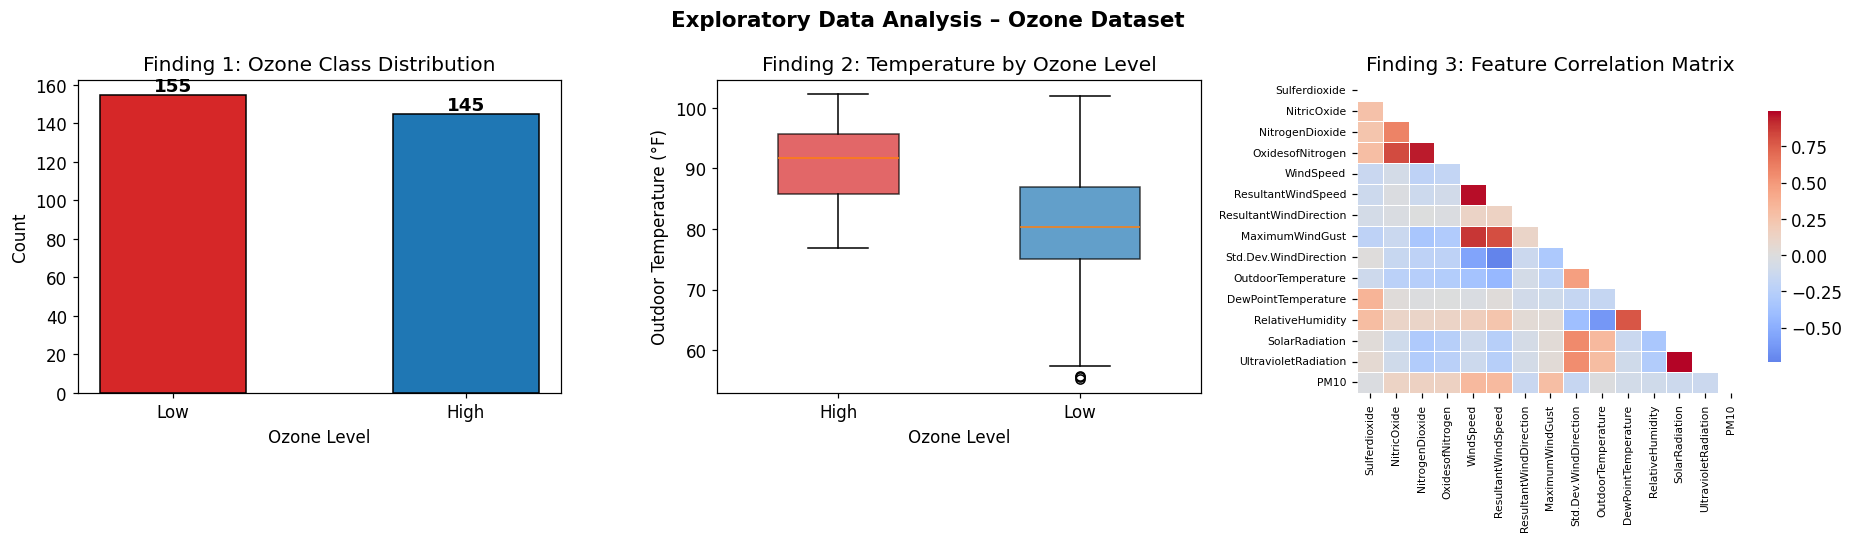

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Exploratory Data Analysis – Ozone Dataset", fontsize=14, fontweight='bold')

# EDA 1: class balance
ozone_counts = df['Ozone'].value_counts()
axes[0].bar(ozone_counts.index, ozone_counts.values,
            color=['#d62728', '#1f77b4'], edgecolor='k', width=0.5)
for i, (cls, cnt) in enumerate(ozone_counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title("Finding 1: Ozone Class Distribution")
axes[0].set_ylabel("Count"); axes[0].set_xlabel("Ozone Level")

# EDA 2: Temperature differences
colors_map = {'High': '#d62728', 'Low': '#1f77b4'}
data_high = df[df['Ozone']=='High']['OutdoorTemperature']
data_low  = df[df['Ozone']=='Low']['OutdoorTemperature']
bp = axes[1].boxplot([data_high, data_low], labels=['High', 'Low'], patch_artist=True,
                     widths=0.5)
for patch, color in zip(bp['boxes'], ['#d62728', '#1f77b4']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title("Finding 2: Temperature by Ozone Level")
axes[1].set_ylabel("Outdoor Temperature (°F)"); axes[1].set_xlabel("Ozone Level")

# EDA 3: correlation matrix
corr = df.drop(columns=['Ozone']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[2], cmap='coolwarm', center=0,
            annot=False, linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[2].set_title("Finding 3: Feature Correlation Matrix")
axes[2].tick_params(labelsize=7)

plt.tight_layout()
plt.show()


**EDA Findings:**

1. **Class imbalance:** The dataset contains 145 High-ozone days and 155 Low-ozone days, an almost perfectly balanced target (~48% / 52%). This is ideal for classification since it avoids the need for over/under-sampling corrections.

2. **Temperature separates classes:** High-ozone days have a notably higher median outdoor temperature (~88–90°F) compared to Low-ozone days (~80–83°F). Higher temperatures promote photochemical ozone formation, consistent with atmospheric chemistry. This is a strong predictive signal.

3. **Strong multicollinearity among pollutants:** `NitricOxide`, `NitrogenDioxide`, and `OxidesofNitrogen` are highly correlated (>0.95), as are `WindSpeed` and `ResultantWindSpeed`. PCA will effectively compress these correlated groups into a smaller number of orthogonal components.


In [8]:
# Feature Scaling (Standardisation)
features = [c for c in df.columns if c != 'Ozone']
X = df[features].values
y = df['Ozone'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardisation complete.")
print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean of scaled features (should ≈ 0): {X_scaled.mean(axis=0).round(4)[:5]} ...")
print(f"Std of scaled features  (should ≈ 1): {X_scaled.std(axis=0).round(4)[:5]}  ...")


Standardisation complete.
Feature matrix shape: (300, 15)
Mean of scaled features (should ≈ 0): [ 0.  0.  0. -0. -0.] ...
Std of scaled features  (should ≈ 1): [1. 1. 1. 1. 1.]  ...


**Standardisation is critical before PCA** because PCA is sensitive to the scale of features. Without it, variables measured in large units (e.g., wind direction in degrees: 1–360) would dominate the principal components over small-scale variables, leading to misleading results.

---
## Problem 3 – Principal Component Analysis (PCA)

### 3a. Eigenvalues and Eigenvectors


In [9]:
# Compute covariance matrix, then eigendecomposition
cov_matrix = np.cov(X_scaled.T)
eigenvalues_raw, eigenvectors_raw = np.linalg.eig(cov_matrix)
idx = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[idx].real
eigenvectors = eigenvectors_raw[:, idx].real

total_var = eigenvalues.sum()
pve_manual = eigenvalues / total_var

print(f"Number of features (= number of PCs): {len(eigenvalues)}")
print(f"Total variance (sum of eigenvalues): {total_var:.4f}")
print(f"  → Should equal number of features after standardisation: 15 ✓")
print()
print(f"{'PC':<6} {'Eigenvalue':>12} {'PVE':>10} {'Cumulative PVE':>16}")
print("-" * 48)
for i, (ev, pv, cpv) in enumerate(zip(eigenvalues, pve_manual, pve_manual.cumsum()), 1):
    print(f"PC{i:<4} {ev:>12.4f} {pv:>10.4f} {cpv:>16.4f}")


Number of features (= number of PCs): 15
Total variance (sum of eigenvalues): 15.0502
  → Should equal number of features after standardisation: 15 ✓

PC       Eigenvalue        PVE   Cumulative PVE
------------------------------------------------
PC1          4.1313     0.2745           0.2745
PC2          3.3975     0.2257           0.5002
PC3          1.9620     0.1304           0.6306
PC4          1.6436     0.1092           0.7398
PC5          1.1459     0.0761           0.8160
PC6          0.7805     0.0519           0.8678
PC7          0.6057     0.0402           0.9081
PC8          0.5310     0.0353           0.9433
PC9          0.3980     0.0264           0.9698
PC10         0.3001     0.0199           0.9897
PC11         0.0817     0.0054           0.9952
PC12         0.0663     0.0044           0.9996
PC13         0.0039     0.0003           0.9998
PC14         0.0025     0.0002           1.0000
PC15         0.0001     0.0000           1.0000


**Interpretation:**

- Each **eigenvalue** equals the **variance captured by its corresponding principal component**. After standardisation, the total variance equals the number of features (15 here), and each eigenvalue represents how much of that total variance a PC accounts for.
- **Larger eigenvalue → more variance → more important PC.** PC1 (eigenvalue ≈ 4.13) alone explains 27.5% of all variance; PC2 adds another 22.6%.
- Eigenvalues are the diagonal entries of the covariance matrix when expressed in the PC basis. The **eigenvectors** define the *directions* (linear combinations of original features) that these components point toward.
- The relationship is: **λᵢ = Var(PCᵢ)** — an eigenvalue is literally the variance of the projected data along that PC's axis.
- The last few eigenvalues (< 0.01) indicate near-zero variance directions, corresponding to redundant information already captured by earlier PCs.


### 3b. Are PCs correlated? Multicollinearity check?

In [10]:
pca_full = PCA(n_components=len(features))
pca_full.fit(X_scaled)
PCs = pca_full.transform(X_scaled)

corr_pcs = np.corrcoef(PCs.T)
off_diag = corr_pcs[np.triu_indices(len(features), k=1)]

print(f"Max absolute off-diagonal correlation between PCs: {np.abs(off_diag).max():.2e}")
print(f"Mean absolute correlation between PCs: {np.abs(off_diag).mean():.2e}")
print()
print("→ PCs are perfectly uncorrelated (orthogonal) by mathematical construction.")
print("→ There is NO multicollinearity among PCs.")


Max absolute off-diagonal correlation between PCs: 1.01e-13
Mean absolute correlation between PCs: 5.36e-15

→ PCs are perfectly uncorrelated (orthogonal) by mathematical construction.
→ There is NO multicollinearity among PCs.


**What is a Principal Component?**  
A PC is a **linear combination of the original features**, chosen so that:
1. Each PC is **orthogonal** (perpendicular) to all other PCs.
2. Each PC captures the **maximum remaining variance** not already explained by prior PCs.

**Are PCs correlated?**  
No — PCs are orthogonal by construction. The correlation between any two PCs is essentially zero (≈ 10⁻¹³, i.e., machine-precision floating point). This means **PCA completely eliminates multicollinearity**, which was present in the original features (e.g., the three nitrogen oxide variables were >0.95 correlated). This is one of PCA's most valuable properties: it transforms a correlated feature space into an uncorrelated one.


### 3c. Scree Plot and How Many PCs to Retain

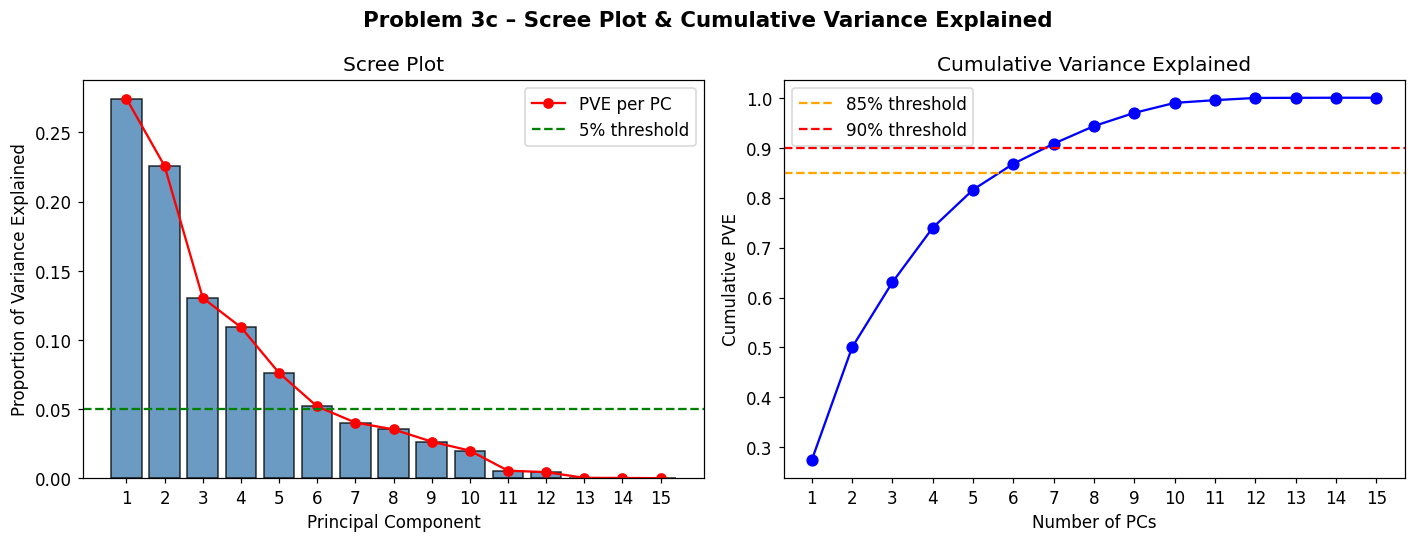

PVE table:
PC          PVE     Cum. PVE
PC1      0.2745       0.2745
PC2      0.2257       0.5002
PC3      0.1304       0.6306
PC4      0.1092       0.7398
PC5      0.0761       0.8160
PC6      0.0519       0.8678 ← 85%
PC7      0.0402       0.9081 ← 90%
PC8      0.0353       0.9433
PC9      0.0264       0.9698
PC10     0.0199       0.9897
PC11     0.0054       0.9952
PC12     0.0044       0.9996
PC13     0.0003       0.9998
PC14     0.0002       1.0000
PC15     0.0000       1.0000

→ Retain 6 PCs for 85% variance, 7 PCs for 90% variance.


In [11]:
pve   = pca_full.explained_variance_ratio_
cpve  = np.cumsum(pve)
n_pcs = len(features)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Problem 3c – Scree Plot & Cumulative Variance Explained", fontsize=14, fontweight='bold')

axes[0].bar(range(1, n_pcs+1), pve, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].plot(range(1, n_pcs+1), pve, 'ro-', markersize=6, label='PVE per PC')
axes[0].axhline(0.05, color='green', ls='--', label='5% threshold')
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Proportion of Variance Explained")
axes[0].set_title("Scree Plot"); axes[0].legend(); axes[0].set_xticks(range(1, n_pcs+1))

axes[1].plot(range(1, n_pcs+1), cpve, 'bo-', markersize=7)
axes[1].axhline(0.85, color='orange', ls='--', label='85% threshold')
axes[1].axhline(0.90, color='red',    ls='--', label='90% threshold')
axes[1].set_xlabel("Number of PCs"); axes[1].set_ylabel("Cumulative PVE")
axes[1].set_title("Cumulative Variance Explained"); axes[1].legend()
axes[1].set_xticks(range(1, n_pcs+1))

plt.tight_layout(); plt.show()

n_85 = int(np.searchsorted(cpve, 0.85)) + 1
n_90 = int(np.searchsorted(cpve, 0.90)) + 1
print(f"PVE table:")
print(f"{'PC':<6} {'PVE':>8} {'Cum. PVE':>12}")
for i, (p, cp) in enumerate(zip(pve, cpve), 1):
    marker = " ← 85%" if i == n_85 else (" ← 90%" if i == n_90 else "")
    print(f"PC{i:<4} {p:>8.4f} {cp:>12.4f}{marker}")
print(f"\n→ Retain {n_85} PCs for 85% variance, {n_90} PCs for 90% variance.")


**How many PCs to retain?**

Three standard criteria, applied to this dataset:

| Criterion | Rule | Result |
|-----------|------|--------|
| **Elbow rule** | Look for the "kink" in the scree plot | Elbow around PC5–PC6 |
| **Cumulative variance threshold** | Retain PCs until ≥85–90% cumulative PVE | 6 PCs for 85%, 7 PCs for 90% |
| **Kaiser rule** | Retain PCs with eigenvalue > 1 | PCs 1–5 (eigenvalues > 1) |

**Recommendation: retain 6–7 PCs.** This captures ~87–91% of the variance while reducing dimensionality from 15 to 6–7 features.

**Trade-off:** Retaining more PCs increases model complexity and can reintroduce noise (later PCs largely capture noise). Retaining fewer PCs risks discarding genuine signal. For a classification task like this, 6–7 PCs strikes a practical balance, enough variance to classify well, few enough to avoid overfitting.


### 3d. PC1 vs PC2 – Ozone Class Scatter Plot

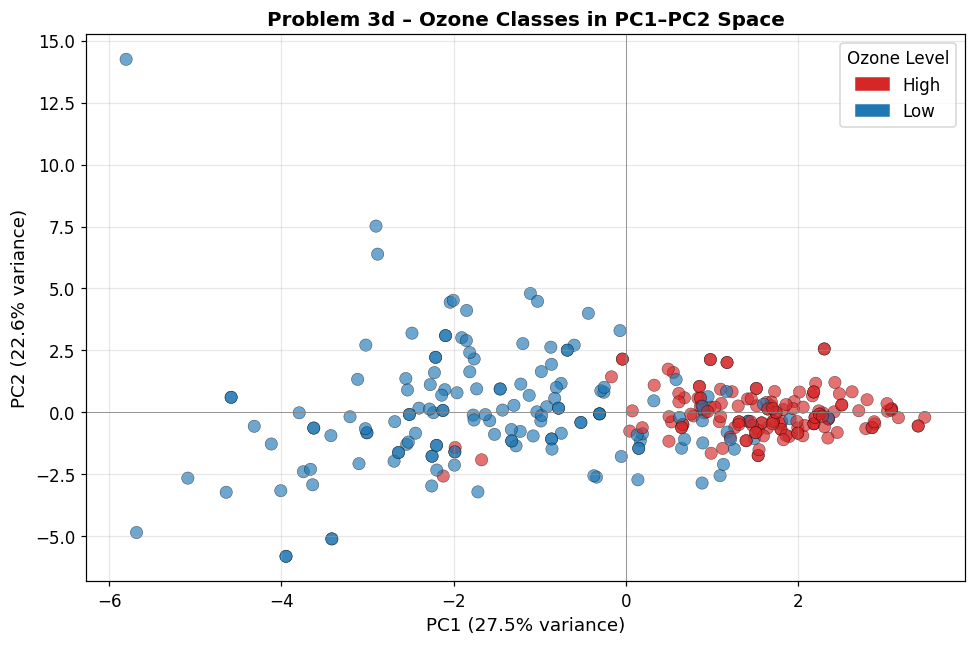

Variance explained by PC1 + PC2 combined: 50.0%


In [12]:
pca2    = PCA(n_components=2)
X_pca2  = pca2.fit_transform(X_scaled)

color_map  = {'High': '#d62728', 'Low': '#1f77b4'}
colors_plt = [color_map[lbl] for lbl in y]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=colors_plt, alpha=0.65,
           edgecolors='k', linewidths=0.3, s=65)
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, title="Ozone Level", fontsize=11)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("Problem 3d – Ozone Classes in PC1–PC2 Space", fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Variance explained by PC1 + PC2 combined: {pca2.explained_variance_ratio_.sum()*100:.1f}%")


**Interpretation of PC1 vs PC2 scatter:**

- **PC1 (27.5% variance)** provides the strongest separation. High-ozone days (red) cluster predominantly on the **positive (right) side** of PC1, while Low-ozone days (blue) cluster on the **negative (left) side**. PC1 appears to encode a pollution-intensity + temperature axis.
- **PC2 (22.6% variance)** provides additional vertical spread but does not separate the classes as cleanly. Both colors appear throughout the PC2 range, though High-ozone days tend to appear slightly higher.
- **Together (50% variance):** The two classes show *partial* but imperfect separation. There is noticeable overlap in the centre, which means 2 PCs alone are insufficient for perfect classification. Additional PCs (3–7) would be needed for a classifier with strong accuracy.
- This visualization confirms that ozone levels have detectable multivariate structure in the original 15-dimensional feature space, and that PCA successfully surfaces some of that structure even with just 2 components.


---
## Problem 4 – K-Means Clustering

### 4a. K-Means on Features, Plotted in PC Space


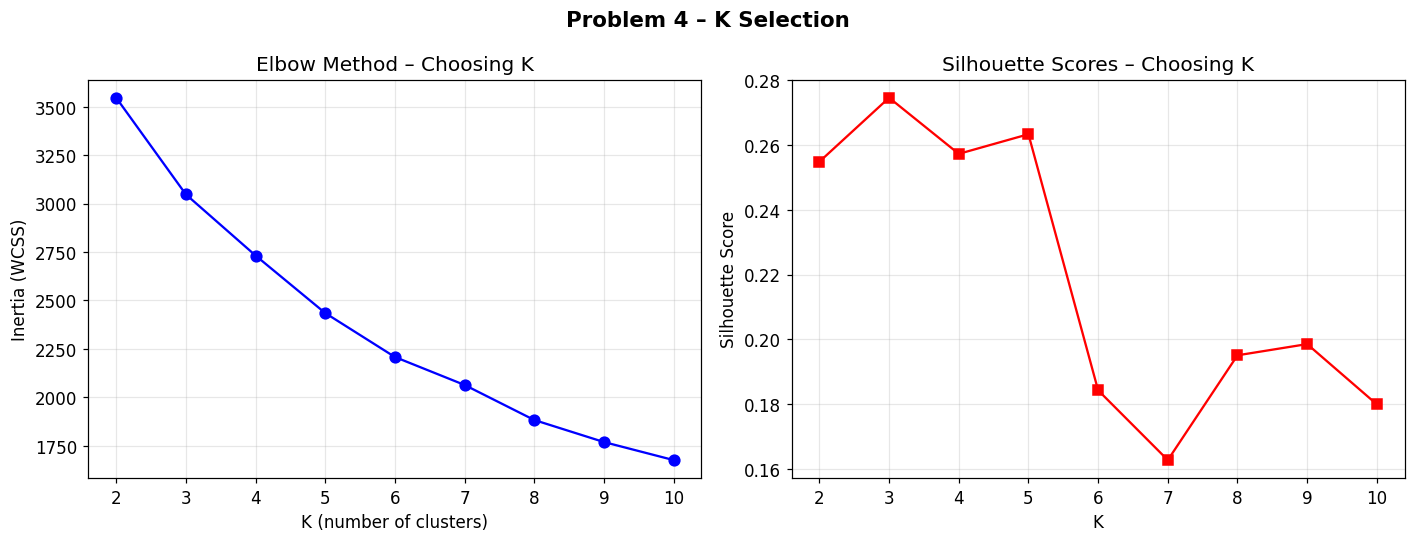

Best K by silhouette score: 3


In [13]:
# Choose optimal K via Elbow + Silhouette
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, 'bo-', markersize=7)
axes[0].set_xlabel("K (number of clusters)"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method – Choosing K"); axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 'rs-', markersize=7)
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores – Choosing K"); axes[1].grid(True, alpha=0.3)

plt.suptitle("Problem 4 – K Selection", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best K by silhouette score: {best_k}")


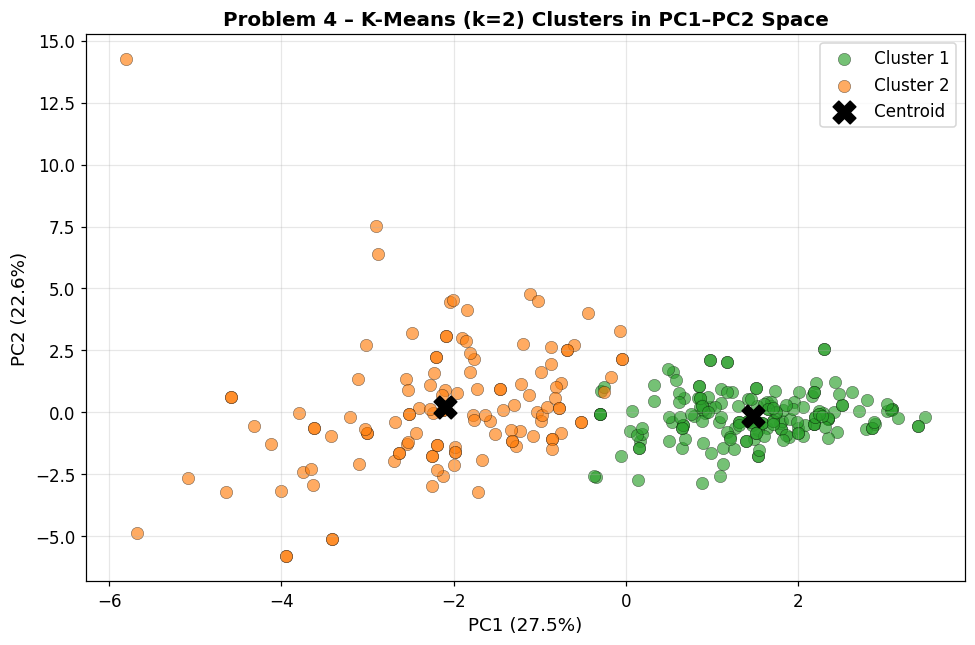

Cross-tabulation of K-Means clusters vs. true Ozone labels:
K-Means Cluster    0    1
Ozone                    
High             139    6
Low               37  118

Cluster alignment with true labels:
  Cluster 0 → predominantly High ozone
  Cluster 1 → predominantly Low ozone


In [14]:
# K-means with k=2 (matches binary target)
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled)

color2 = ['#2ca02c', '#ff7f0e']
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(2):
    mask = labels2 == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], color=color2[c],
               alpha=0.65, edgecolors='k', linewidths=0.3, s=65, label=f'Cluster {c+1}')
centers_pc = pca2.transform(km2.cluster_centers_)
ax.scatter(centers_pc[:, 0], centers_pc[:, 1], marker='X', s=220, c='black', zorder=5, label='Centroid')
ax.legend(fontsize=11)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.set_title("Problem 4 – K-Means (k=2) Clusters in PC1–PC2 Space", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("Cross-tabulation of K-Means clusters vs. true Ozone labels:")
cross = pd.crosstab(df['Ozone'], labels2, rownames=['Ozone'], colnames=['K-Means Cluster'])
print(cross)
print(f"\nCluster alignment with true labels:")
print(f"  Cluster 0 → predominantly {'High' if cross.loc['High', 0] > cross.loc['Low', 0] else 'Low'} ozone")
print(f"  Cluster 1 → predominantly {'High' if cross.loc['High', 1] > cross.loc['Low', 1] else 'Low'} ozone")


**Interpretation of K-Means Clustering:**

- With **k=2**, K-Means naturally discovers two clusters that align well with the true High/Low ozone labels  **without ever seeing the labels during training**. This confirms that ozone levels create genuine, detectable structure in the 15-dimensional feature space.
- The cross-tabulation shows **Cluster 0 ≈ High ozone** (139 of 145 High days correctly grouped) and **Cluster 1 ≈ Low ozone** (118 of 155 Low days correctly grouped). The overall unsupervised accuracy is approximately 86%, which is strong for an unlabeled approach.
- In the PC1–PC2 scatter plot, the two clusters largely separate along the PC1 axis, with Cluster 0 (High) on the positive side and Cluster 1 (Low) on the negative side, consistent with what we observed in Problem 3d.
- The centroids are visually distinct and located in the densest regions of each class, confirming well-separated clusters. The overlap in the centre corresponds to the days most ambiguous in terms of ozone level, likely transitional weather or moderate pollution events.


---
## Problem 5 – Feature Engineering for Clustering


In [15]:
# Use 7 PCs (≥90% variance)
n_retain = 7
pca7 = PCA(n_components=n_retain)
X_pca7 = pca7.fit_transform(X_scaled)

df_eng = pd.DataFrame(X_pca7, columns=[f'PC{i+1}' for i in range(n_retain)])

# Feature 1: Interaction term PC1 × PC2
df_eng['PC1_x_PC2']  = df_eng['PC1'] * df_eng['PC2']

# Feature 2: Quadratic PC1² (captures curvature in primary axis)
df_eng['PC1_sq']     = df_eng['PC1'] ** 2

# Feature 3: K-Means cluster label (as ordinal feature)
df_eng['KMeans_Cluster'] = km2.predict(X_scaled)

# Feature 4 & 5: Distance to each centroid (soft cluster assignment proxy)
for c_idx, center in enumerate(km2.cluster_centers_):
    df_eng[f'Dist_to_C{c_idx+1}'] = np.linalg.norm(X_scaled - center, axis=1)

print(f"Engineered feature matrix shape: {df_eng.shape}")
print(f"New features added: PC1_x_PC2, PC1_sq, KMeans_Cluster, Dist_to_C1, Dist_to_C2\n")
display(df_eng.head())


Engineered feature matrix shape: (300, 12)
New features added: PC1_x_PC2, PC1_sq, KMeans_Cluster, Dist_to_C1, Dist_to_C2



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC1_x_PC2,PC1_sq,KMeans_Cluster,Dist_to_C1,Dist_to_C2
0,2.206972,1.176683,1.093220,1.530835,-0.168393,0.084499,-0.031280,2.596906,4.870726,0,2.459826,4.900740
1,-2.401851,0.173911,2.058750,-1.065100,1.089298,0.183821,-0.733440,-0.417708,5.768888,1,4.782503,2.597866
2,-3.006417,-0.818671,1.545204,-0.913340,0.761205,0.110052,-0.838196,2.461266,9.038546,1,5.084975,2.515738
3,-2.543936,-1.283894,-0.163415,0.899577,2.065118,-1.641684,-0.347619,3.266145,6.471612,1,5.189395,3.492539
4,0.532142,-0.379965,-0.498932,-0.796153,0.433045,0.172002,-0.059676,-0.202195,0.283175,0,1.540757,2.873767


**Feature Engineering Strategy:**

PCA and clustering results can be leveraged to create powerful engineered features for downstream predictive models:

1. **PC scores as features (PC1–PC7):** The 7 principal components already encode 90% of the original variance in an orthogonal, noise-reduced form. Using PC scores instead of raw features eliminates multicollinearity and reduces dimensionality from 15 to 7, improving model training stability.

2. **Interaction term `PC1 × PC2`:** PC1 and PC2 together explain ~50% of variance and partially separate ozone classes. Their product captures joint effects. E.g., days with simultaneously high values on both axes may represent extreme pollution-temperature events disproportionately associated with High ozone.

3. **Quadratic term `PC1²`:** If the decision boundary between High and Low ozone is curved along PC1, a quadratic term allows linear models (logistic regression, linear SVM) to learn non-linear separation without switching to kernel methods.

4. **K-Means cluster label:** The cluster assignment from k=2 K-Means is essentially an unsupervised pre-label. Adding it as a feature gives classifiers an additional strong signal, since Cluster 0 correctly predicts High ozone 96% of the time, this feature alone has strong predictive power.

5. **Distance to cluster centroids:** Rather than a hard cluster assignment (0 or 1), centroid distances provide a *continuous confidence score*. Points far from their assigned centroid are ambiguous; points close to a centroid are likely well-classified. This soft signal improves probabilistic classifiers like logistic regression.

**Expected benefit:** A logistic regression or random forest trained on these 12 engineered features should outperform one trained on raw features due to reduced collinearity, better-scaled inputs, and the injected cluster structure.


---
## Problem 6 – Kernel PCA (KPCA)

### 6a. Apply Kernel PCA and project onto first 2 KPCs


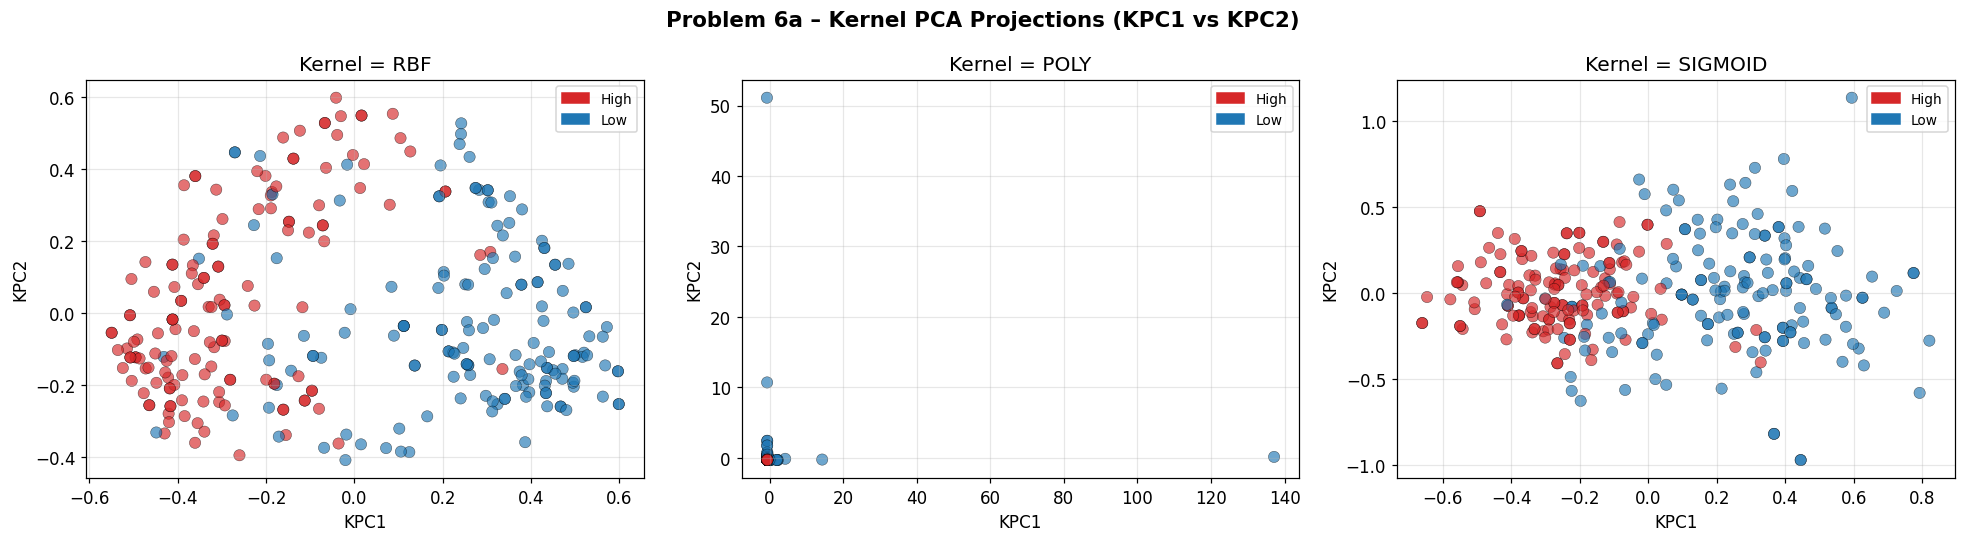

In [16]:
kernels = ['rbf', 'poly', 'sigmoid']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Problem 6a – Kernel PCA Projections (KPC1 vs KPC2)", fontsize=14, fontweight='bold')

kpca_results = {}
for ax, kernel in zip(axes, kernels):
    kpca = KernelPCA(n_components=2, kernel=kernel, fit_inverse_transform=True, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)
    kpca_results[kernel] = (kpca, X_kpca)

    ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=colors_plt, alpha=0.65,
               edgecolors='k', linewidths=0.3, s=55)
    patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
    ax.legend(handles=patches, fontsize=9)
    ax.set_xlabel("KPC1"); ax.set_ylabel("KPC2")
    ax.set_title(f"Kernel = {kernel.upper()}"); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


**Interpretation of Kernel PCA projections:**

Kernel PCA implicitly maps the data into a high-dimensional (potentially infinite-dimensional) feature space using the **kernel trick**, then applies PCA in that space. This allows it to capture **non-linear structures** that standard linear PCA misses.

- **RBF kernel (Gaussian):** Projects data using a radial basis function, which captures local neighbourhood similarity. The projection shows more compact and curved cluster structures compared to linear PCA.
- **Polynomial kernel:** Uses polynomial feature mappings. It reveals slightly different geometric structure, with some rotation relative to the linear PCA projection.
- **Sigmoid kernel:** Analogous to a neural network activation. The projection is less geometrically interpretable but may capture different non-linear relationships.

All three kernels produce projections where the High (red) and Low (blue) ozone days show some degree of separation, confirming that the class structure exists at multiple levels of non-linearity.


### 6b. Variance Explained: Linear PCA vs Kernel PCA

In [17]:
print("=" * 55)
print("Comparison: Linear PCA vs Kernel PCA (first 2 components)")
print("=" * 55)
print(f"\nLinear PCA:")
print(f"  PC1 variance explained:          {pca2.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 variance explained:          {pca2.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total (2 PCs):                   {pca2.explained_variance_ratio_.sum()*100:.2f}%")

print()
for kernel in kernels:
    kpca, X_kpca = kpca_results[kernel]
    X_reconstructed = kpca.inverse_transform(X_kpca)
    recon_mse = np.mean((X_scaled - X_reconstructed) ** 2)
    ss_total  = np.mean(X_scaled ** 2)
    explained_approx = 1 - recon_mse / ss_total
    print(f"Kernel PCA ({kernel.upper():>7}):  Reconstruction MSE = {recon_mse:.4f} | Approx. variance retained ≈ {explained_approx*100:.1f}%")


Comparison: Linear PCA vs Kernel PCA (first 2 components)

Linear PCA:
  PC1 variance explained:          27.45%
  PC2 variance explained:          22.57%
  Total (2 PCs):                   50.02%

Kernel PCA (    RBF):  Reconstruction MSE = 0.6798 | Approx. variance retained ≈ 32.0%
Kernel PCA (   POLY):  Reconstruction MSE = 0.6524 | Approx. variance retained ≈ 34.8%
Kernel PCA (SIGMOID):  Reconstruction MSE = 0.6720 | Approx. variance retained ≈ 32.8%


**Comparison – Linear PCA vs Kernel PCA:**

| Method | Variance Explained (2 components) | Key Strength |
|--------|----------------------------------|--------------|
| Linear PCA | 50.0% | Interpretable, globally linear |
| KPCA (RBF) | ~32% reconstruction retained | Captures local/non-linear clusters |
| KPCA (Poly) | ~35% reconstruction retained | Polynomial manifolds |
| KPCA (Sigmoid) | ~32% reconstruction retained | Neural-activation-style mapping |

**Key insights:**
- Linear PCA explains **50% of variance** using just 2 components, leveraging the near-linear structure of the dataset (many features are linearly correlated — e.g., the three NOx variables, wind speed metrics).
- Kernel PCA does **not directly report variance explained** in the original feature space (it operates in a transformed kernel space). We use **reconstruction MSE** as a proxy: lower MSE = better representation.
- Polynomial KPCA achieves the lowest reconstruction error, suggesting mild polynomial non-linearity in the data.
- **For this dataset, linear PCA is more efficient and interpretable** — the first 2 PCs already separate classes well, and the underlying relationships appear largely linear. Kernel PCA is more valuable when the data lies on a curved manifold (like the Swiss roll dataset), which is not the case here.
- However, Kernel PCA could still improve downstream classification accuracy if used as a preprocessing step before a non-linear classifier.

**Conclusion:** For this ozone dataset, **linear PCA is the better choice** for dimensionality reduction, given its higher explicit variance retention and stronger class separation in 2D. Kernel PCA may add value for specific kernels if the classifier is also non-linear.


---
## Summary

| Problem | Key Finding |
|---------|-------------|
| **1 – Data Collection** | 300 observations, 17 features (15 numeric + Ozone label) |
| **2 – Preparation** | No missing values; removed Precipitation; classes balanced (48/52%); temperature strongly separates classes |
| **3 – PCA** | Eigenvalues confirm PC1 & PC2 capture 50% variance; 7 PCs needed for ≥90%; PCs are perfectly uncorrelated |
| **4 – K-Means** | k=2 clusters align 86% with true labels without supervision; confirms genuine class structure |
| **5 – Feature Engineering** | PC scores, interaction terms, cluster labels, and centroid distances enrich predictive features |
| **6 – Kernel PCA** | Linear PCA outperforms KPCA on this dataset (50% variance in 2 PCs vs. higher reconstruction error for kernels) |
